
# Importações

In [1]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from shap.plots import colors

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

MODELOS = ["MLP", "RF", "XGBoost"]
SEEDS = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
HORIZONTE = 3
OTIMIZADORES = ["PSO", "SA"]
N_CLASSES = [2, 3, 4, 5, 6, 7, 8, 9, 10]
N_ITER = 15
N_SOLUCOES = 15
SEED = 100


def reset_seed(rnd_seed=SEED):
    os.environ['PYTHONHASHSEED'] = '0'
    random.seed(rnd_seed)
    np.random.seed(rnd_seed)


warnings.filterwarnings("ignore")
reset_seed()

C:\Users\eduar\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Melhores Features

In [2]:
df_features = pd.read_csv("./resultados/features/fitness_features_regressao.csv", sep=";", decimal=".")

df_features = df_features.sort_values("RRMSE").head(1).reset_index(drop=True)
df_features = pd.DataFrame(
    columns=str(df_features.iloc[0]["FEATURES"]).replace("(", '').replace(")", '').replace("'", "").split(", "))

df_features = df_features.columns

df_features

Index(['TEMP_MÉD_MIN_MENS', 'TEMP_MÉD_MÉD_MENS', 'PRECIPITAÇÃO_MÉD_MENS',
       'TEMP_MIN_MAX_MENS', 'TEMP_MAX_MIN_MENS', 'PRECIPITAÇÃO_MIN_MENS',
       'TEMP_MAX_MAX_MENS', 'DIA_DA_SEMANA_dom', 'DIA_DA_SEMANA_seg',
       'DIA_DA_SEMANA_sáb', 'DIA_DA_SEMANA_ter', 'MÊS_abr', 'MÊS_ago',
       'MÊS_fev', 'MÊS_jun', 'MÊS_mai', 'MÊS_nov', 'ANO_2021', 'ANO_2022',
       'ANO_2023', 'ANO_2015', 'ANO_2016', 'ANO_2017', 'ANO_2018', 'ANO_2019',
       'CAMPUS_ASTORGA', 'CAMPUS_CAMPO LARGO', 'CAMPUS_CAPANEMA',
       'CAMPUS_CASCAVEL', 'CAMPUS_CORONEL VIVIDA', 'CAMPUS_CURITIBA',
       'CAMPUS_GOIOERÊ', 'CAMPUS_IVAIPORÃ', 'CAMPUS_JAGUARIAÍVA',
       'CAMPUS_LONDRINA - CENTRO', 'CAMPUS_PALMAS', 'CAMPUS_PARANAGUÁ',
       'CAMPUS_PINHAIS', 'CAMPUS_TELÊMACO BORBA', 'CAMPUS_UMUARAMA',
       'CURSOS_TEC_SUBSEQUENTE', 'CURSOS_GRAD_MATUTINO',
       'CURSOS_GRAD_VESPERTINO', 'CURSOS_GRAD_NOTURNO', 'CURSOS_POS', 'FÉRIAS',
       'COVID', 'LAG_01', 'LAG_02', 'LAG_03', 'LAG_05', 'LAG_07', 'LAG_09'],


## Melhores Parâmetros

In [3]:
def get_modelo(nome, n_classes):
    if nome == "MLP":
        mlp = MLPClassifier(hidden_layer_sizes=(int(best[("MLP", n_classes)]["Hidden Layers"]),),
                            activation=best[("MLP", n_classes)]["Activation"],
                            alpha=best[("MLP", n_classes)]["Alpha"],
                            random_state=SEED)
        return mlp

    if nome == "RF":
        return RandomForestClassifier(random_state=SEED,
                                      n_estimators=int(best[("RF", n_classes)]["N_estimators"]),
                                      max_depth=int(best[("RF", n_classes)]["Max_depth"]),
                                      min_samples_split=int(best[("RF", n_classes)]["Min_samples_split"]),
                                      min_samples_leaf=int(best[("RF", n_classes)]["Min_samples_leaf"]))

    if nome == "XGBoost":
        return XGBClassifier(random_state=SEED,
                             n_estimators=int(best[("XGBoost", n_classes)]["N_estimators"]),
                             max_depth=int(best[("XGBoost", n_classes)]["Max_depth"]),
                             booster=best[("XGBoost", n_classes)]["Booster"],
                             reg_lambda=best[("XGBoost", n_classes)]["Lambda"],
                             reg_alpha=best[("XGBoost", n_classes)]["Alpha"],
                             updater="coord_descent" if best[("XGBoost", n_classes)]["Booster"] == "gblinear" else None)


best = {}
for modelo in MODELOS:
    for classes in N_CLASSES:
        df_aux = pd.read_csv(
            f"./resultados/otimização - classificação/{classes} classes/{classes} CLASSES BEST {modelo}.csv", sep=';',
            decimal='.', header=0)

        best[(modelo, classes)] = df_aux.iloc[0]


# Treino e Teste

In [4]:
def treino(previsor, dados_treino, features):
    x_treino = dados_treino[features].to_numpy()
    y_treino = dados_treino["CLASSE"].to_numpy()

    previsor.fit(x_treino, y_treino)
    return previsor


def teste(previsor, historico_campus, x_teste, features):
    historico = historico_campus[["CLASSE"]].copy()
    x_teste = x_teste[features].copy()

    previsoes = []

    for i_test in range(HORIZONTE):
        row = x_teste.iloc[[i_test]].copy()
        historico = pd.concat([historico, pd.DataFrame([0], columns=["CLASSE"], index=[i_test])], axis=0)

        # Recalcula os lags conforme os valores previstos pelo modelo
        lags = pd.DataFrame({f'LAG_{i:02d}': historico["CLASSE"].shift(i) for i in range(1, 12 + 1) if
                             f'LAG_{i:02d}' in features}).tail(1)
        row.update(lags)

        prev = previsor.predict(row.to_numpy())[0]

        row["CLASSE"] = prev
        previsoes.append(prev)
        historico.update(row)
    return pd.DataFrame({"CONSUMO PREVISTO": previsoes}, index=x_teste.index)

## Treinamento Local


In [5]:
for classes in N_CLASSES:
    df = pd.read_csv(f"./dados/classes/{classes} classes/{classes}_classes_normalizadas_lagadas.csv", sep=';',
                     decimal='.')

    for campus, dados in df.sort_values('DATA').groupby("CAMPUS"):
        dados = dados.set_index('DATA')
        dados_treino, dados_teste = train_test_split(dados, test_size=HORIZONTE, random_state=SEED, shuffle=False)

        df_previsoes = pd.DataFrame(columns=MODELOS, index=dados_teste.index)

        for nome_modelo in MODELOS:
            # Treina o modelo com os dados do campus atual
            modelo = treino(get_modelo(nome_modelo, classes), dados_treino, df_features)

            # Testa o modelo com os dados do campus atual
            previsoes = teste(modelo, dados_treino, dados_teste, df_features)
            df_previsoes[[nome_modelo]] = previsoes[["CONSUMO PREVISTO"]]
        os.makedirs(f"resultados/classificação - local/{classes} classes/{HORIZONTE} meses", exist_ok=True)
        df_previsoes.to_csv(
            f"resultados/classificação - local/{classes} classes/{HORIZONTE} meses/PREVISÕES {HORIZONTE}M - {campus}.csv",
            sep=";", decimal=".",
            index=True)


## Treinamento Global


In [6]:

for classes in N_CLASSES:
    df = pd.read_csv(f"./dados/classes/{classes} classes/{classes}_classes_normalizadas_lagadas.csv", sep=';',
                     decimal='.')

    df_treino = []
    df_teste = []

    for campus, dados in df.sort_values('DATA').groupby("CAMPUS"):
        dados["CAMPUS"] = campus

        dados_treino, dados_teste = train_test_split(dados, test_size=HORIZONTE,
                                                     shuffle=False)

        df_treino.append(dados_treino)
        df_teste.append(dados_teste)

    df_treino = pd.DataFrame(pd.concat(df_treino, ignore_index=True))
    df_teste = pd.DataFrame(pd.concat(df_teste, ignore_index=True))

    for campus, dados_teste in df_teste.sort_values('DATA').groupby("CAMPUS"):
        dados_teste = dados_teste.set_index('DATA')
        df_previsoes = pd.DataFrame(columns=MODELOS, index=dados_teste.index)

        for nome_modelo in MODELOS:
            # Treina o modelo com os dados de todos os campi
            modelo = treino(get_modelo(nome_modelo, classes), df_treino, df_features)

            # Testa o modelo com os dados do campus atual
            previsoes = teste(modelo, df_treino[df_treino["CAMPUS"] == campus], dados_teste, df_features)
            df_previsoes[[nome_modelo]] = previsoes[["CONSUMO PREVISTO"]]

        os.makedirs(f"resultados/classificação - global/{classes} classes/{HORIZONTE} meses", exist_ok=True)
        df_previsoes.to_csv(
            f"resultados/classificação - global/{classes} classes/{HORIZONTE} meses/PREVISÕES {HORIZONTE}M - {campus}.csv",
            sep=";", decimal=".",
            index=True)


# Análise dos Resultados

In [10]:
def ts_comparacao_classes(acc):
    plt.figure(figsize=(12, 4.5))
    plt.rcParams['xtick.labelsize'] = 13
    plt.rcParams['ytick.labelsize'] = 14
    plt.rcParams.update({'font.size': 12})
    plt.rcParams['axes.prop_cycle'] = plt.cycler(
        color=["blue", "green", "darkgoldenrod", colors.red_rgb, "purple", "cyan", "slategrey", "coral"])

    for modelo in MODELOS:
        plt.plot(N_CLASSES, acc[modelo] * 100, label=modelo, marker='o')

    plt.xlabel('NÚMERO DE CLASSES')
    plt.ylabel('ACURÁCIA MÉDIA (%)')

    ax = plt.gca()
    ax.set_facecolor('white')
    ax.set_ylim(0, 100)
    plt.grid(True, color='grey', linestyle="--", linewidth=0.5)
    plt.legend(facecolor='white')

    return plt


def medidas_desempenho(valor_real, valores_previstos):
    df_desempenho = pd.DataFrame(columns=["ACC"], index=valores_previstos.columns)

    for nome_modelo in valores_previstos.columns:
        df_desempenho.loc[nome_modelo] = [
            accuracy_score(valor_real["CLASSE"].tail(HORIZONTE), valores_previstos[nome_modelo].tail(HORIZONTE)),
        ]

    return df_desempenho


## Treinamento Local

,MLP,RF,XGBoost
2,0.75,0.708333,0.777778
3,0.5,0.513889,0.513889
4,0.5,0.458333,0.361111
5,0.416667,0.458333,0.361111
6,0.430556,0.319444,0.305556
7,0.194444,0.263889,0.208333
8,0.194444,0.291667,0.166667
9,0.180556,0.25,0.166667
10,0.361111,0.319444,0.152778


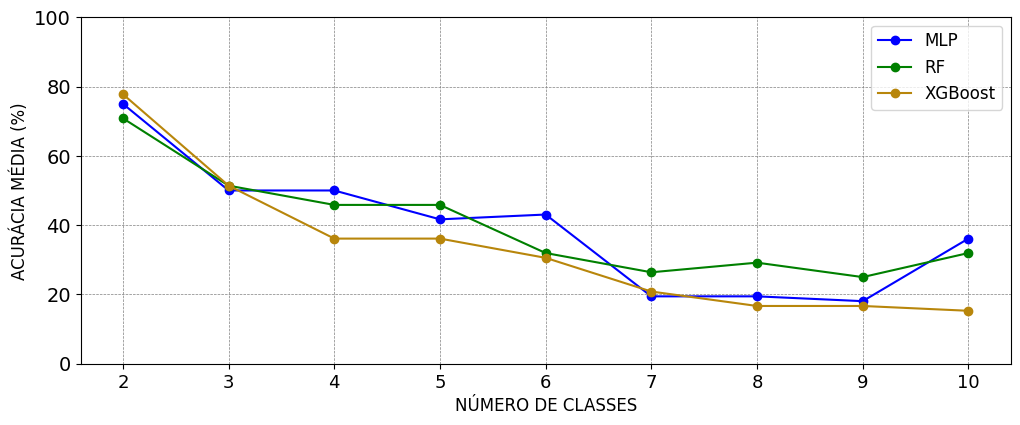

In [11]:
df_acc_todos = pd.DataFrame(columns=MODELOS, index=N_CLASSES)

for classes in N_CLASSES:
    df_real = pd.read_csv(f"./dados/classes/{classes} classes/{classes}_classes_normalizadas.csv", sep=';',
                          decimal='.')

    df_acc = pd.DataFrame(columns=MODELOS, index=df_real["CAMPUS"].unique())
    acc_classes = []

    for campus, dados in df_real.sort_values("DATA").groupby("CAMPUS"):
        try:
            consumo_previsto = pd.read_csv(
                f"resultados/classificação - local/{classes} classes/{HORIZONTE} meses/PREVISÕES {HORIZONTE}M - {campus}.csv",
                sep=";", decimal=".", header=0)
        except Exception as e:
            continue

        consumo_previsto["DATA"] = pd.to_datetime(consumo_previsto["DATA"])
        consumo_previsto = consumo_previsto.set_index("DATA")

        dados["DATA"] = pd.to_datetime(dados["DATA"])
        dados = dados.set_index("DATA")

        df_desempenho = medidas_desempenho(dados, consumo_previsto)
        df_acc.loc[campus] = df_desempenho["ACC"]
        acc_classes.append(df_desempenho["ACC"])

        df_desempenho.to_csv(f"resultados/classificação - local/{classes} classes/ACURÁCIA {HORIZONTE}M {campus}.csv",
                             sep=";", decimal=".", index=True)

    # Calcula as medidas de desempenho
    media_ACC = df_acc.mean()
    pior_ACC = (df_acc.eq(df_acc.min(axis=1), axis=0).sum(axis=0))
    melhor_ACC = (df_acc.eq(df_acc.max(axis=1), axis=0).sum(axis=0))

    df_acc.loc["MELHOR DESEMPENHO"] = melhor_ACC
    df_acc.loc["PIOR DESEMPENHO"] = pior_ACC
    df_acc.loc["SCORE DESEMPENHO (MELHOR - PIOR)"] = melhor_ACC - pior_ACC
    df_acc.loc["MÉDIA ACC"] = media_ACC

    # Atualiza o DataFrame global com a média de acurácia para o número de classes atual
    if acc_classes:
        df_acc_todos.loc[classes] = pd.concat(acc_classes, axis=1).mean(axis=1)

# Exibe o gráfico com as médias globais
display(df_acc_todos)
plt = ts_comparacao_classes(df_acc_todos)
plt.savefig(f"resultados/classificação - local/DESEMPENHO MÉDIO {HORIZONTE}M.png", bbox_inches='tight')
plt.show()



## Treinamento Global

,MLP,RF,XGBoost
2,0.805556,0.875,0.847222
3,0.652778,0.736111,0.680556
4,0.638889,0.611111,0.5
5,0.513889,0.541667,0.527778
6,0.305556,0.555556,0.5
7,0.291667,0.333333,0.430556
8,0.236111,0.402778,0.472222
9,0.25,0.347222,0.388889
10,0.263889,0.277778,0.208333


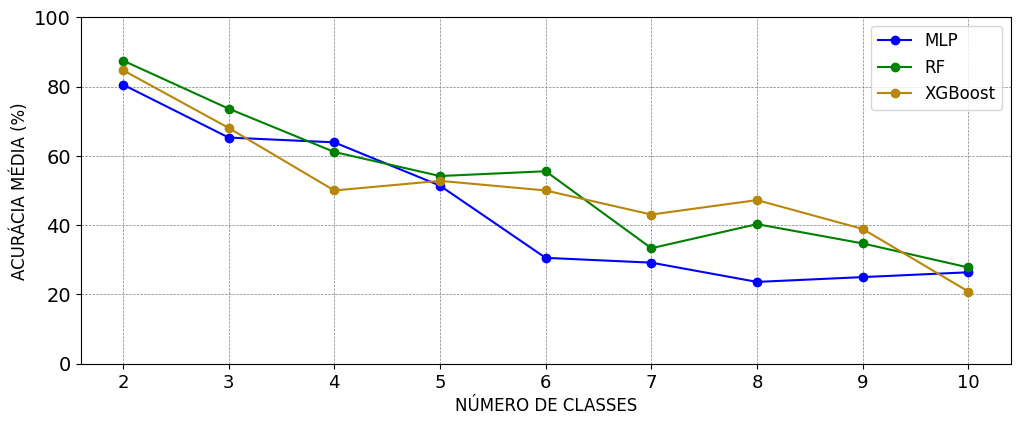

In [12]:
df_acc_todos = pd.DataFrame(columns=MODELOS, index=N_CLASSES)

for classes in N_CLASSES:
    df_real = pd.read_csv(f"./dados/classes/{classes} classes/{classes}_classes_normalizadas.csv", sep=';',
                          decimal='.')

    df_acc = pd.DataFrame(columns=MODELOS, index=df_real["CAMPUS"].unique())
    acc_classes = []

    for campus, dados in df_real.sort_values("DATA").groupby("CAMPUS"):
        try:
            consumo_previsto = pd.read_csv(
                f"resultados/classificação - global/{classes} classes/{HORIZONTE} meses/PREVISÕES {HORIZONTE}M - {campus}.csv",
                sep=";", decimal=".", header=0)
        except Exception as e:
            continue

        consumo_previsto["DATA"] = pd.to_datetime(consumo_previsto["DATA"])
        consumo_previsto = consumo_previsto.set_index("DATA")

        dados["DATA"] = pd.to_datetime(dados["DATA"])
        dados = dados.set_index("DATA")

        df_desempenho = medidas_desempenho(dados, consumo_previsto)
        df_acc.loc[campus] = df_desempenho["ACC"]
        acc_classes.append(df_desempenho["ACC"])

        df_desempenho.to_csv(f"resultados/classificação - global/{classes} classes/ACURÁCIA {HORIZONTE}M {campus}.csv",
                             sep=";", decimal=".", index=True)

    # Calcula as medidas de desempenho
    media_ACC = df_acc.mean()
    pior_ACC = (df_acc.eq(df_acc.min(axis=1), axis=0).sum(axis=0))
    melhor_ACC = (df_acc.eq(df_acc.max(axis=1), axis=0).sum(axis=0))

    df_acc.loc["MELHOR DESEMPENHO"] = melhor_ACC
    df_acc.loc["PIOR DESEMPENHO"] = pior_ACC
    df_acc.loc["SCORE DESEMPENHO (MELHOR - PIOR)"] = melhor_ACC - pior_ACC
    df_acc.loc["MÉDIA ACC"] = media_ACC

    # Atualiza o DataFrame global com a média de acurácia para o número de classes atual
    if acc_classes:
        df_acc_todos.loc[classes] = pd.concat(acc_classes, axis=1).mean(axis=1)

# Exibe o gráfico com as médias globais
display(df_acc_todos)
plt = ts_comparacao_classes(df_acc_todos)
plt.savefig(f"resultados/classificação - global/DESEMPENHO MÉDIO {HORIZONTE}M.png", bbox_inches='tight')

plt.show()

